In [1]:
from Src.Feature_engineering import data
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from Src.Data_utils import differencing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
from statsmodels.tsa.vector_ar.vecm import select_coint_rank,select_order

data=data
print(data)

            Labor Productivity  Government Spending       GDP  Consumption  \
date                                                                         
1985-01-01                 1.4             6.858666  8.349997     7.870471   
1985-04-01                 1.2             6.873876  8.365181     7.885893   
1985-07-01                 2.0             6.892306  8.386349     7.906805   
1985-10-01                 2.3             6.904179  8.399331     7.921463   
1986-01-01                 3.2             6.915182  8.413585     7.947007   
...                        ...                  ...       ...          ...   
2018-10-01                 0.5             8.432377  9.948359     9.552731   
2019-01-01                 1.0             8.452761  9.957578     9.552837   
2019-04-01                 1.6             8.462726  9.971050     9.567315   
2019-07-01                 2.4             8.470786  9.985859     9.581628   
2019-10-01                 3.6             8.475595  9.995758   

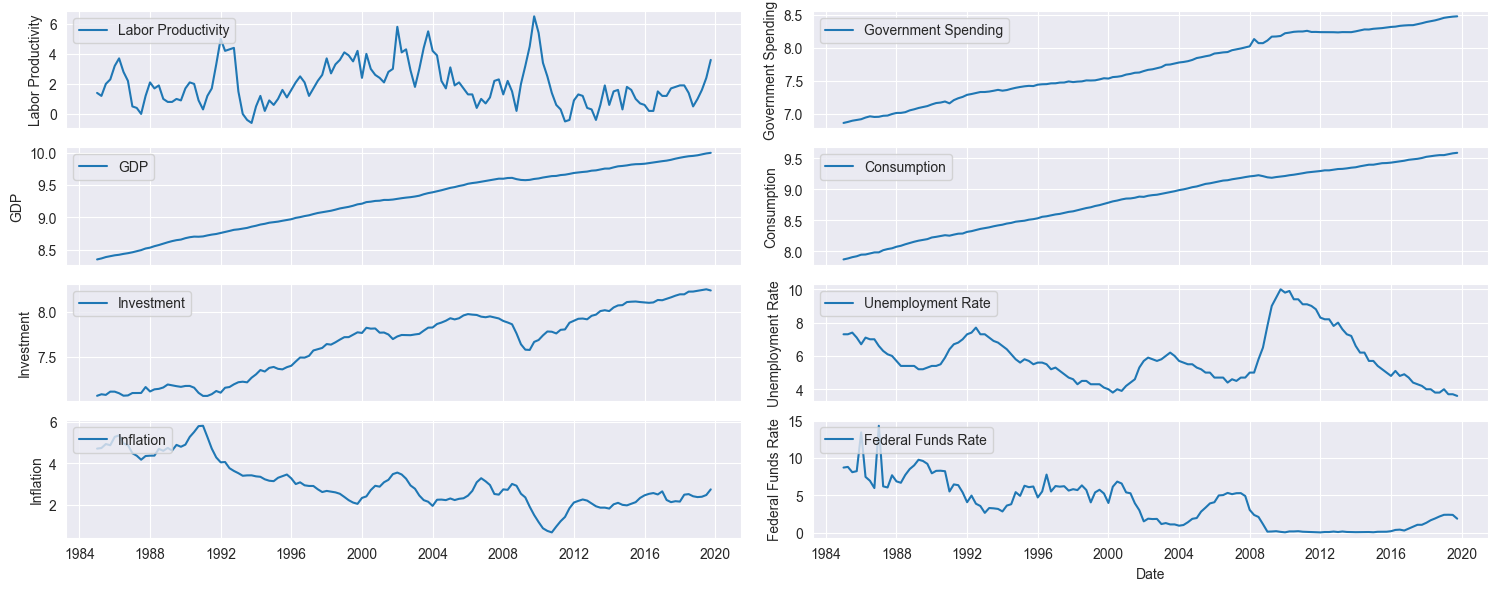

In [2]:
fig, axes = plt.subplots(4, 2, figsize=(15, 6), sharex=True)
axes = axes.flatten()
for i, column in enumerate(data.columns):
    axes[i].plot(data.index, data[column], label=column, color='tab:blue')
    axes[i].set_ylabel(column)
    axes[i].legend(loc='upper left')

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [3]:
##Calculates unit roots to formally test stationarity
def dickey_fuller_test(data_test,regression):
    if "date" in data_test.columns:
        data_test = data_test.drop(["date"], axis=1)
    for i in data_test.columns:
        adf_result = adfuller(data_test[i], regression=regression)
        print(f"{i}, ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}")


dickey_fuller_test(data[["GDP","Investment","Government Spending","Consumption"]],"ct") ##Dickey fuller test with trend


dickey_fuller_test(data[["Labor Productivity","Unemployment Rate","Federal Funds Rate","Inflation"]],"c") ##Dickey fuller test without trend
##All variables are I(1)

GDP, ADF Statistic: -1.5177120377712583, p-value: 0.8229918614753691
Investment, ADF Statistic: -2.2909125315433077, p-value: 0.43898277704623184
Government Spending, ADF Statistic: -2.2711103960987122, p-value: 0.44999061068061025
Consumption, ADF Statistic: -1.0183662140952743, p-value: 0.9415914347643528
Labor Productivity, ADF Statistic: -2.1233791540409457, p-value: 0.23521822424671113
Unemployment Rate, ADF Statistic: -2.829505738922552, p-value: 0.05418111878194498
Federal Funds Rate, ADF Statistic: -1.82495255069433, p-value: 0.3681456893923396
Inflation, ADF Statistic: -1.700534677871335, p-value: 0.43083701581932493


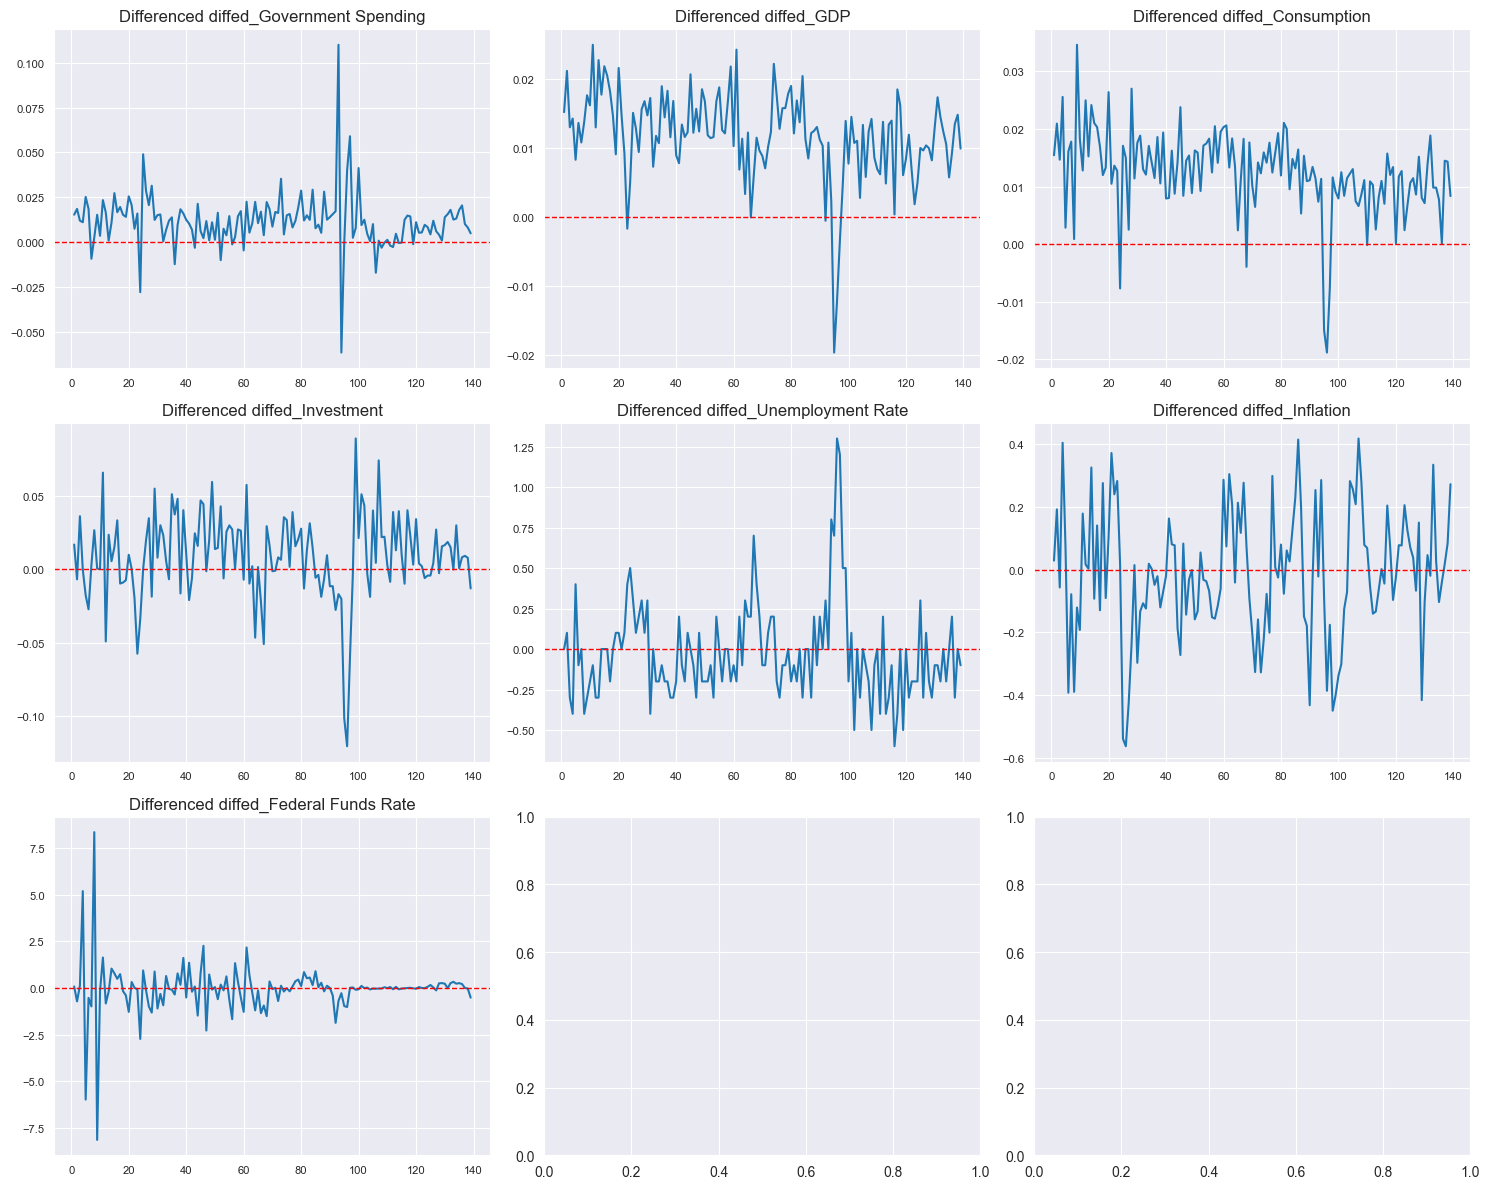

In [4]:
##Differencing the data and calculating Dickey Fuller on the new data
Differenced_data = differencing(data)


##All the data is I(0)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

# Plot each column
for i, col in enumerate(Differenced_data.columns):
    Differenced_data[col].plot(ax=axes[i], color='#1f77b4', title=f"Differenced {col}")
    axes[i].axhline(y=0, color='r', linestyle='--', linewidth=1) # Add a zero line
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='both', which='major', labelsize=8)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

##There is a huge shock in 2008-07 and rebound in 2008-10 (Collapse in Lehman Brothers)

In [5]:
test=dickey_fuller_test(Differenced_data,"c")
print(test)

Differenced_data["diffed_Federal Funds Rate"].nlargest(5)


diffed_Government Spending, ADF Statistic: -3.329240726061813, p-value: 0.013620947543449774
diffed_GDP, ADF Statistic: -4.978334346564528, p-value: 2.449186892177183e-05
diffed_Consumption, ADF Statistic: -4.482346071810488, p-value: 0.00021159886981952952
diffed_Investment, ADF Statistic: -8.5832427070683, p-value: 7.627626522810702e-14
diffed_Unemployment Rate, ADF Statistic: -4.045618939595674, p-value: 0.0011896004777655193
diffed_Inflation, ADF Statistic: -4.976062419655731, p-value: 2.4745805107806054e-05
diffed_Federal Funds Rate, ADF Statistic: -3.874694478370291, p-value: 0.0022291795107416915
None


8     8.36
4     5.20
46    2.27
61    2.18
11    1.64
Name: diffed_Federal Funds Rate, dtype: float64

In [6]:
##Calculate descriptive statistics on stationary time series
Differenced_data.describe()

,diffed_Government Spending,diffed_GDP,diffed_Consumption,diffed_Investment,diffed_Unemployment Rate,diffed_Inflation,diffed_Federal Funds Rate
count,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000
mean,0.011633,0.011840,0.012370,0.008422,-0.026619,-0.014150,-0.049353
std,0.015425,0.006306,0.007270,0.029096,0.293054,0.203927,1.401996
min,-0.061717,-0.019710,-0.018802,-0.120635,-0.600000,-0.562750,-8.130000
25%,0.004404,0.009133,0.008985,-0.006103,-0.200000,-0.127528,-0.265000
50%,0.011834,0.012260,0.012714,0.007917,-0.100000,-0.022190,0.000000
75%,0.016514,0.015637,0.016342,0.026863,0.100000,0.093062,0.250000
max,0.110010,0.024957,0.034585,0.089204,1.300000,0.417404,8.360000


In [7]:
data.index.freq = 'QS'
lag_order = select_order(data, maxlags=10,deterministic="ci")
print(lag_order.summary())


 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -45.76     -43.98*   1.348e-20     -45.04*
1       -45.98      -42.79   1.089e-20      -44.68
2       -46.14      -41.53   9.605e-21      -44.26
3       -46.41      -40.38   7.739e-21      -43.96
4       -46.69      -39.24  6.442e-21*      -43.66
5       -46.73      -37.86   7.164e-21      -43.12
6       -46.70      -36.41   9.095e-21      -42.52
7       -46.82      -35.11   1.091e-20      -42.06
8       -47.68      -34.55   7.007e-21      -42.34
9       -48.10      -33.56   8.157e-21      -42.19
10     -49.09*      -33.13   6.703e-21      -42.61
--------------------------------------------------


In [8]:
##Johansen cointegration test using r metric with lag 1 (BIC suggested 0 so I am picking the second best, I use BIC because of big penalty for overfit)

rank_test = select_coint_rank(data,
                              det_order=1, ##Accounting for trend
                              k_ar_diff=1)
print(rank_test.summary())
## There exists 2 cointegration relations that we need to adjust for

Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   8          220.2          175.2
  1   8          142.8          139.3
  2   8          102.1          107.3
-------------------------------------


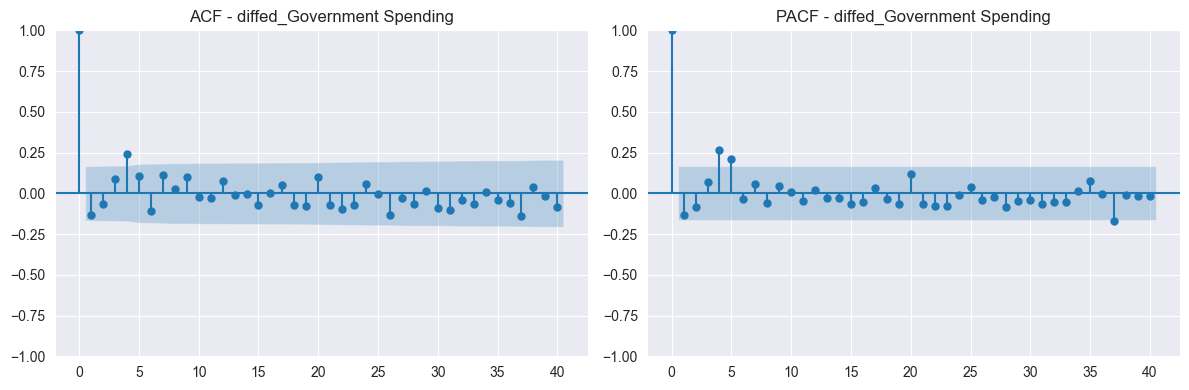

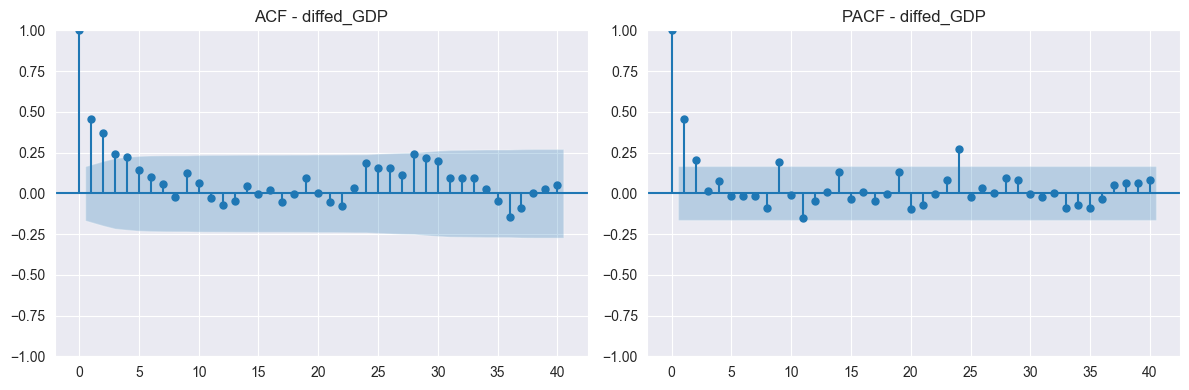

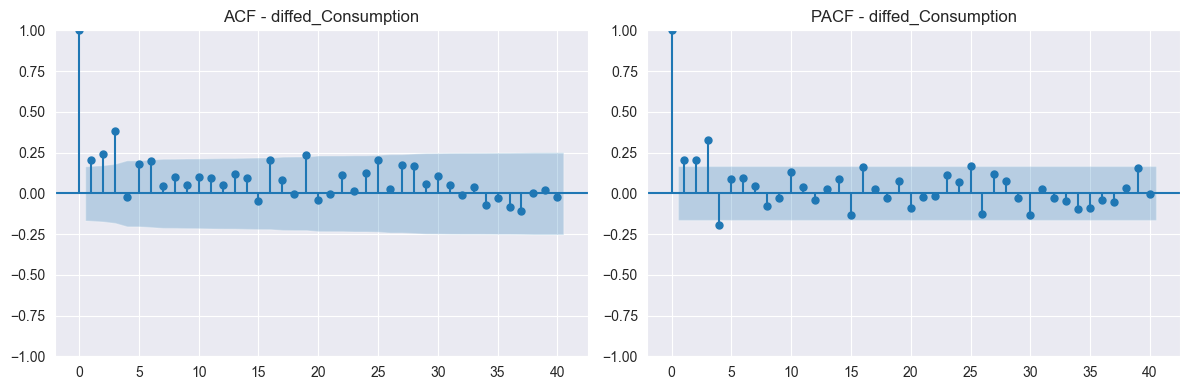

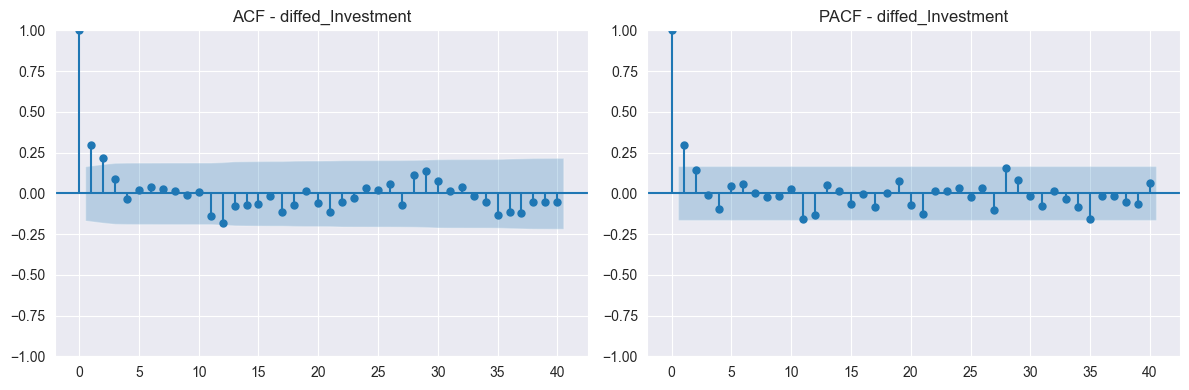

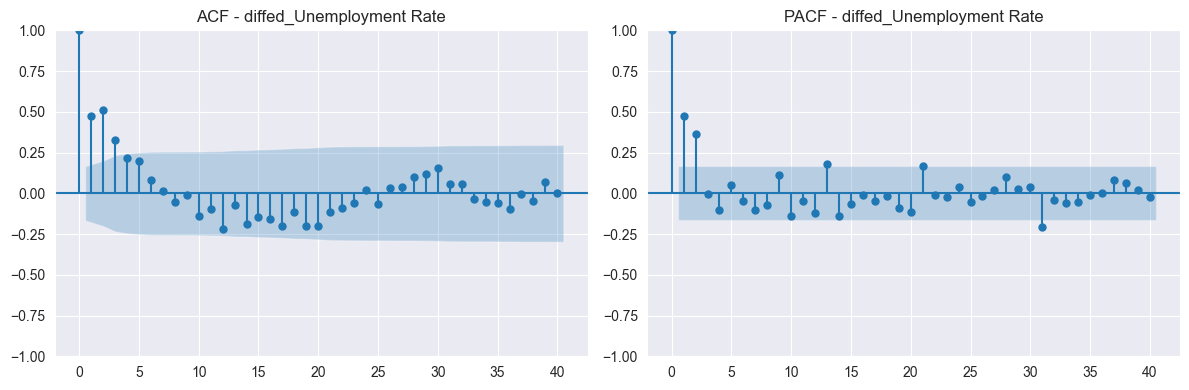

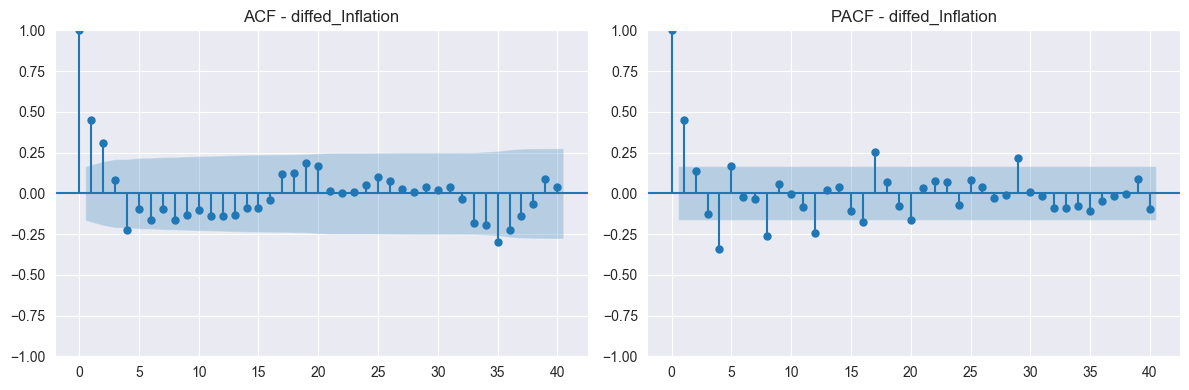

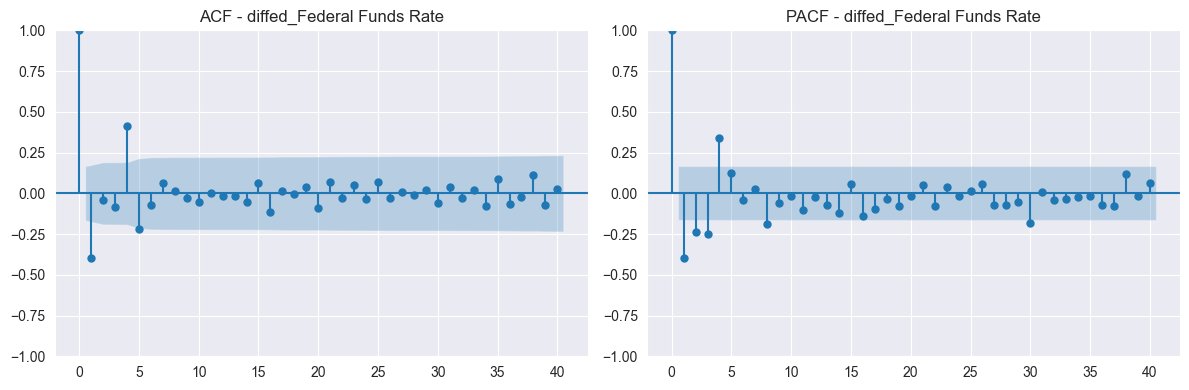

In [9]:
for column in Differenced_data.columns:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(Differenced_data[column].dropna(), ax=axes[0], lags=40)
    axes[0].set_title(f"ACF - {column}")

    plot_pacf(Differenced_data[column].dropna(), ax=axes[1], lags=40, method="ywm")
    axes[1].set_title(f"PACF - {column}")

    plt.tight_layout()
    plt.show()

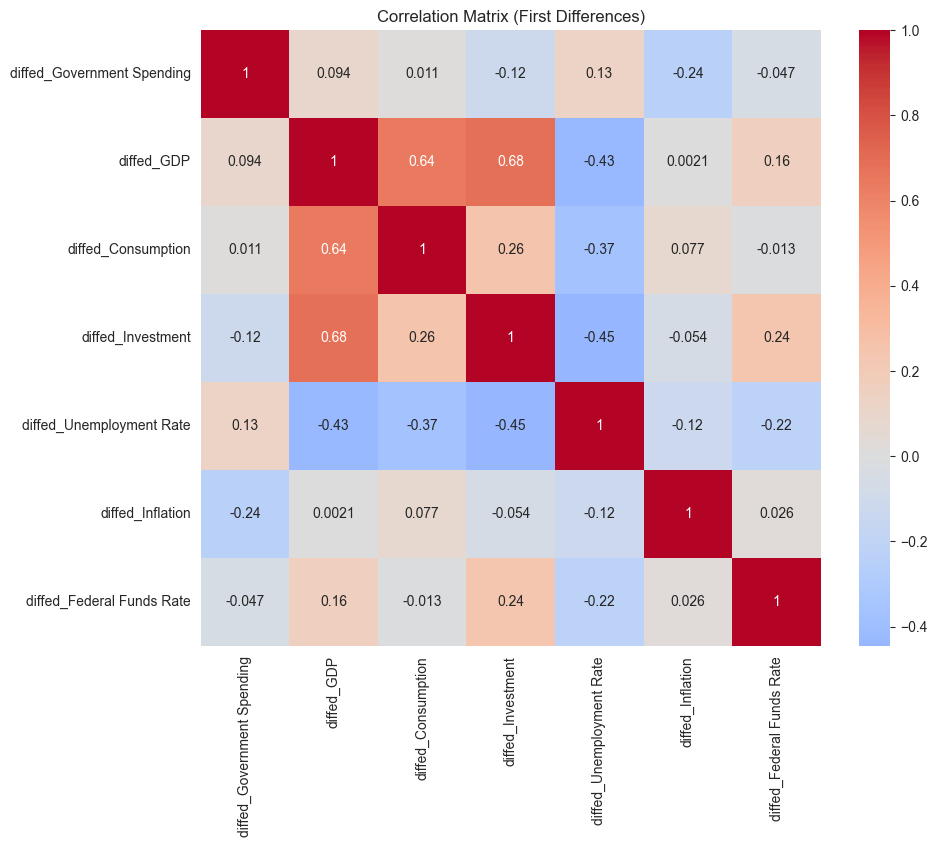

In [10]:
corr_diff = Differenced_data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_diff, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (First Differences)")
plt.show()


ADF test on time series differences shows that all of the variables are I(1).

There is a huge shock in 2008-07-01 and recovery pack in 2008-10-10. Furthermore, there is a big structural break in the early 1980's in the interest rate

From BIC we can see that the optimal lag order is 0. However, BIC puts a really heavy penalty on the number of observations and the amount of parameters. AIC shows that the optimal lag is 10. I will use the lag of 1 because I don't want to overfit the model. Also a lot of lags takes away degrees of freedom making predictions worse.

Johansen test indicates that there exists 2 cointegration relationships in the data that we need to adjust for.

ACF shows that there doesn't exist any seasonality in the differenced data.

As expected in correlations consumption and investment are highly correlated with GDP this is because of GDP structure: GDP= C+I+G-NX. What is unusual is that federal funds rate is positively related to GDP. This might due to high interest rates in the early 1980's.